# Trajectory Distribution Fuzzing in Highway Roundabout

This notebook demonstrates trajectory distribution fuzzing for the HighwayEnv roundabout environment.

**Key Components** (now in `src/` modules):
- `ScenarioParams`: Dataclass for configurable observation, action, and environment disturbances
- `SimulatedEnv`: Custom roundabout environment with fuzzable parameters
- `ScenarioFuzzer`: Class for rollouts and finding critical failure scenarios

**Usage**: Create a `ScenarioFuzzer` with env and model, then call `fuzzer.rollout()` or `fuzzer.optimize()`

In [ ]:
# Uncomment to install dependencies
# !pip install gymnasium stable_baselines3 opencv-python highway_env torch

In [1]:
# Use dummy video driver to prevent window from appearing
import os
os.environ["SDL_VIDEODRIVER"] = "dummy" # uncomment later

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import DQN

import numpy as np

# Import from src modules (auto-registers SimulatedEnv-v0)
from src import (
    ScenarioParams,
    GaussianMixtureParam,
    NormalParam,
    ProbabilityParam,
    BetaParam,
    NOMINAL,
    SQRT_2,
    SimulatedEnv,
    ScenarioFuzzer,
    FuzzerConfig,
    PARAM_NAMES,
    compute_robustness,
    weights_from_vector,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
objc[88088]: Class SDLApplication is implemented in both /Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x2e6c0c890) and /Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x302e612c8). One of the two will be used. Which one is undefined.
objc[88088]: Class SDLAppDelegate is implemented in both /Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x2e6c0c8e0) and /Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x302e61318). One of the two will be used. W

In [ ]:
# Environment auto-registers when SimulatedEnv is imported from src
# (registration happens in src/simulated_env.py)

In [2]:
# Define scenario parameters (customize as needed)
setup = ScenarioParams(
    # Observation disturbances
    initial_position_x=GaussianMixtureParam(
        p=[1.0], 
        mu=[0.0, 0.0], 
        sigma=[0.005, 0.005]
    ),
    initial_position_y=GaussianMixtureParam(
        p=[1.0], 
        mu=[0.0, 0.0], 
        sigma=[0.005, 0.005]
    ),
    velocity_x=GaussianMixtureParam(
        p=[1.0],
        mu=[0.0, 0.0],
        sigma=[SQRT_2 * 0.005 / 0.1, SQRT_2 * 0.005 / 0.1]
    ),
    velocity_y=GaussianMixtureParam(
        p=[1.0],
        mu=[0.0, 0.0],
        sigma=[SQRT_2 * 0.005 / 0.1, SQRT_2 * 0.005 / 0.1]
    ),
    # Action disturbances
    high_lvl_ctrl_noise=ProbabilityParam(p=[0.0]),
    initial_speed=NormalParam(mu=8.0, sigma=0.5),
    initial_heading=ProbabilityParam(p=[0.33, 0.33, 0.33]),
    # Environment disturbances
    politeness=BetaParam(ab=[1, 1]),  # uniform distribution
    other_vehicle_speed=NormalParam(mu=16.0, sigma=2.0),
    entering_vehicle_position=GaussianMixtureParam(
        p=[1.0],
        mu=[5.0, 5.0],  # tip: mu=100.0 can cause more crashes
        sigma=[2.0, 2.0]
    )
)

In [3]:
TRAIN = False
RECORD_VIDEO = False  # Set True to save videos to roundabout_dqn/videos/

# Create the environment (render_mode only needed for video recording)
render_mode = "rgb_array" if RECORD_VIDEO else None
env = gym.make("SimulatedEnv-v0", render_mode=render_mode, scenario_params=setup)
obs, info = env.reset()

# Wrap with RecordVideo if recording
if RECORD_VIDEO:
    env = RecordVideo(
        env, video_folder="roundabout_dqn/videos/", episode_trigger=lambda e: True
    )
    env.unwrapped.set_record_video_wrapper(env)

# Create the model
model = DQN(
    "MlpPolicy",
    env,
    policy_kwargs=dict(net_arch=[256, 256]),
    learning_rate=5e-4,
    buffer_size=15000,
    learning_starts=200,
    batch_size=32,
    gamma=0.8,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=50,
    verbose=1,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [4]:
# Train the model (if needed)
if TRAIN:
    model.learn(total_timesteps=int(2e4))
    model.save("roundabout_dqn/model")
    del model

In [4]:
# Load trained model
model = DQN.load("roundabout_dqn/best_model/best_model.zip", env=env, device="cpu")

# Configure environment
env.unwrapped.config["simulation_frequency"] = 15
env.unwrapped.config.update({
    "observation": {
        "type": "Kinematics",
        "absolute": True,
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-15, 15],
            "vy": [-15, 15],
        },
        "vehicles_count": 5,
    },
})

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [5]:
# Robustness weights
robustness_weights = weights_from_vector([0.2042, 0.1982, 0.4393, 0.0111, 0.1471])

In [6]:
# Define scenario parameters (customize as needed)
params = [4.95776270e+01, 1.87668872e+01, 1.53715955e-01, 5.54054473e+00,
            7.23311281e-01, 3.76688719e+00, 3.77027236e-03, 3.42060315e-02,
            3.42060315e-02, 3.42060315e-02]

    # "entering_vehicle_mu",
    # "other_vehicle_speed",
    # "ctrl_noise_p",
    # "initial_speed_mu",
    # "politeness_alpha",
    # "politeness_beta",
    # "pos_x_sigma",
    # "pos_y_sigma",
    # "vel_x_sigma",
    # "vel_y_sigma",
fuzzed = ScenarioParams(
    
    # [4.95776270e+01, 1.87668872e+01, 1.53715955e-01, 5.54054473e+00,
        # 7.23311281e-01, 3.76688719e+00, 3.77027236e-03, 3.42060315e-02,
        # 3.42060315e-02, 3.42060315e-02]
    # Observation disturbances
    initial_position_x=GaussianMixtureParam(
        p=[1.0], 
        mu=[0.0, 0.0], 
        sigma=[params[6], 0.005]
    ),
    initial_position_y=GaussianMixtureParam(
        p=[1.0], 
        mu=[0.0, 0.0], 
        sigma=[params[7], 0.005]
    ),
    velocity_x=GaussianMixtureParam(
        p=[1.0],
        mu=[0.0, 0.0],
        sigma=[params[8], SQRT_2 * 0.005 / 0.1]
    ),
    velocity_y=GaussianMixtureParam(
        p=[1.0],
        mu=[0.0, 0.0],
        sigma=[params[9], SQRT_2 * 0.005 / 0.1]
    ),
    # Action disturbances
    high_lvl_ctrl_noise=ProbabilityParam(p=[params[2]]),
    initial_speed=NormalParam(mu=params[3], sigma=0.5),
    initial_heading=ProbabilityParam(p=[0.33, 0.33, 0.33]),
    # Environment disturbances
    politeness=BetaParam(ab=[params[4], params[5]]),  # uniform distribution
    other_vehicle_speed=NormalParam(mu=params[1], sigma=2.0),
    entering_vehicle_position=GaussianMixtureParam(
        p=[1.0],
        mu=[params[0], 5.0],  # tip: mu=100.0 can cause more crashes
        sigma=[2.0, 2.0]
    )
)

In [7]:
# Create fuzzer for rollouts
fuzzer = ScenarioFuzzer(env, model, robustness_weights=robustness_weights)
# fuzzer._apply_params(params)

# Run rollouts and collect metrics
N_ROLLOUTS = 500  # to record video
COMPUTE_LOG_PROB = True  
RETURN_SENSITIVITIY = False

logs = []
for i in range(N_ROLLOUTS):
    result = fuzzer.rollout(compute_log_prob=COMPUTE_LOG_PROB, return_sensitivity = RETURN_SENSITIVITIY)
    logs.append(result)
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{N_ROLLOUTS} rollouts")

print(f"\nCollected {len(logs)} rollouts")

/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scal

Completed 10/500 rollouts


/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scal

Completed 20/500 rollouts


/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scal

...

Completed 480/500 rollouts


/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scal

Completed 490/500 rollouts


/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_prob += (alpha - 1) * np.log(pol) + (beta_param  - 1) * np.log(1 - pol)
/Users/dkoffical/Documents/GitHub/StanfordRoundabout/src/fuzzer.py:469: DeprecationWarning: __array_wrap__ must accept context and return_scal

Completed 500/500 rollouts

Collected 500 rollouts


In [ ]:
# # Store logs. Please don't run this unless you really have to. 

# import json
# # Keep index and item together
# failures_with_id = [(i+1, item) for i, item in enumerate(logs) if item['is_failure']]
# sorted_failures_with_id = sorted(failures_with_id, key=lambda x: x[1]['nominal_log_prob'], reverse=True)

# # Prepare sorted_failures_with_id for JSON
# json_failures = [{"id": idx, "item": item} for idx, item in sorted_failures_with_id]

# # Save both logs and failures to JSON
# with open("roundabout_dqn/falsification_results/eval_logs/logs_and_failures.json", "w") as f:
#     json.dump({
#         "logs": logs,
#         "sorted_failures_with_id": json_failures
#     }, f, indent=2)  # indent=2 makes it readable

# # --- Later, to load them ---
# with open("roundabout_dqn/falsification_results/eval_logs/logs_and_failures.json", "r") as f:
#     data = json.load(f)
#     logs_loaded = data["logs"]
#     sorted_failures_loaded = data["sorted_failures_with_id"]

# # Example check
# print(len(logs_loaded), len(sorted_failures_loaded))
# print(sorted_failures_loaded[0]["id"], sorted_failures_loaded[0]["item"]["nominal_log_prob"])



In [15]:
# --- Later, to load them ---
import json
with open("roundabout_dqn/falsification_results/eval_logs/logs_and_failures.json", "r") as f:
    data = json.load(f)
    logs_loaded = data["logs"]
    sorted_failures_loaded = data["sorted_failures_with_id"]

In [ ]:
import os
import shutil

# Move top 10 most likely videos

if RECORD_VIDEO:
    # Paths
    src_dir = "./roundabout_dqn/videos"
    dst_dir = "./roundabout_dqn/videos/most_likely"
    os.makedirs(dst_dir, exist_ok=True)

    # Take top 10 failures (highest nominal_log_prob first)
    top_failures = sorted_failures_loaded[:10]

    for rank, failure in enumerate(top_failures, start=1):
        # Assuming 'item' contains the filename, or we construct it from 'id' or other info
        # If your video files are named like rl-video-episode-3.mp4, we need to know episode number
        original_filename = f"rl-video-episode-{failure['item']['metrics'].get('episode', failure['id'])}.mp4"
        
        src_path = os.path.join(src_dir, original_filename)
        
        # New filename with rank
        new_filename = f"{rank}-{original_filename}"
        dst_path = os.path.join(dst_dir, new_filename)
        
        # Move & rename
        if os.path.exists(src_path):
            shutil.move(src_path, dst_path)
            print(f"Moved: {src_path} → {dst_path}")
        else:
            print(f"File not found: {src_path}")

Moved: ./roundabout_dqn/videos/rl-video-episode-138.mp4 → ./roundabout_dqn/videos/most_likely/1-rl-video-episode-138.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-411.mp4 → ./roundabout_dqn/videos/most_likely/2-rl-video-episode-411.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-81.mp4 → ./roundabout_dqn/videos/most_likely/3-rl-video-episode-81.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-66.mp4 → ./roundabout_dqn/videos/most_likely/4-rl-video-episode-66.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-77.mp4 → ./roundabout_dqn/videos/most_likely/5-rl-video-episode-77.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-63.mp4 → ./roundabout_dqn/videos/most_likely/6-rl-video-episode-63.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-231.mp4 → ./roundabout_dqn/videos/most_likely/7-rl-video-episode-231.mp4
Moved: ./roundabout_dqn/videos/rl-video-episode-82.mp4 → ./roundabout_dqn/videos/most_likely/8-rl-video-episode-82.mp4
Moved: ./roundabout_dqn/videos/rl-video-ep

## Plot Log Probability vs Robustness Factors

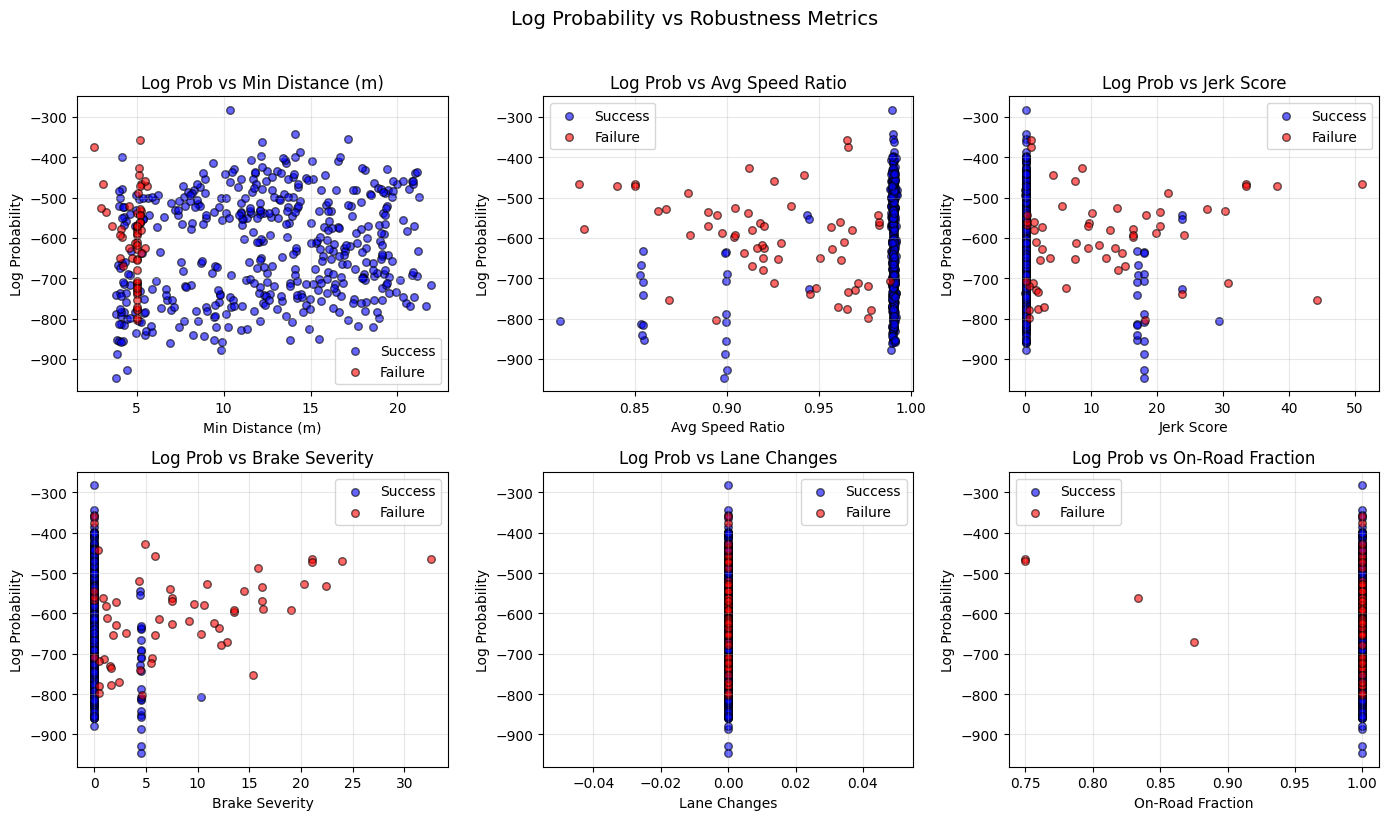

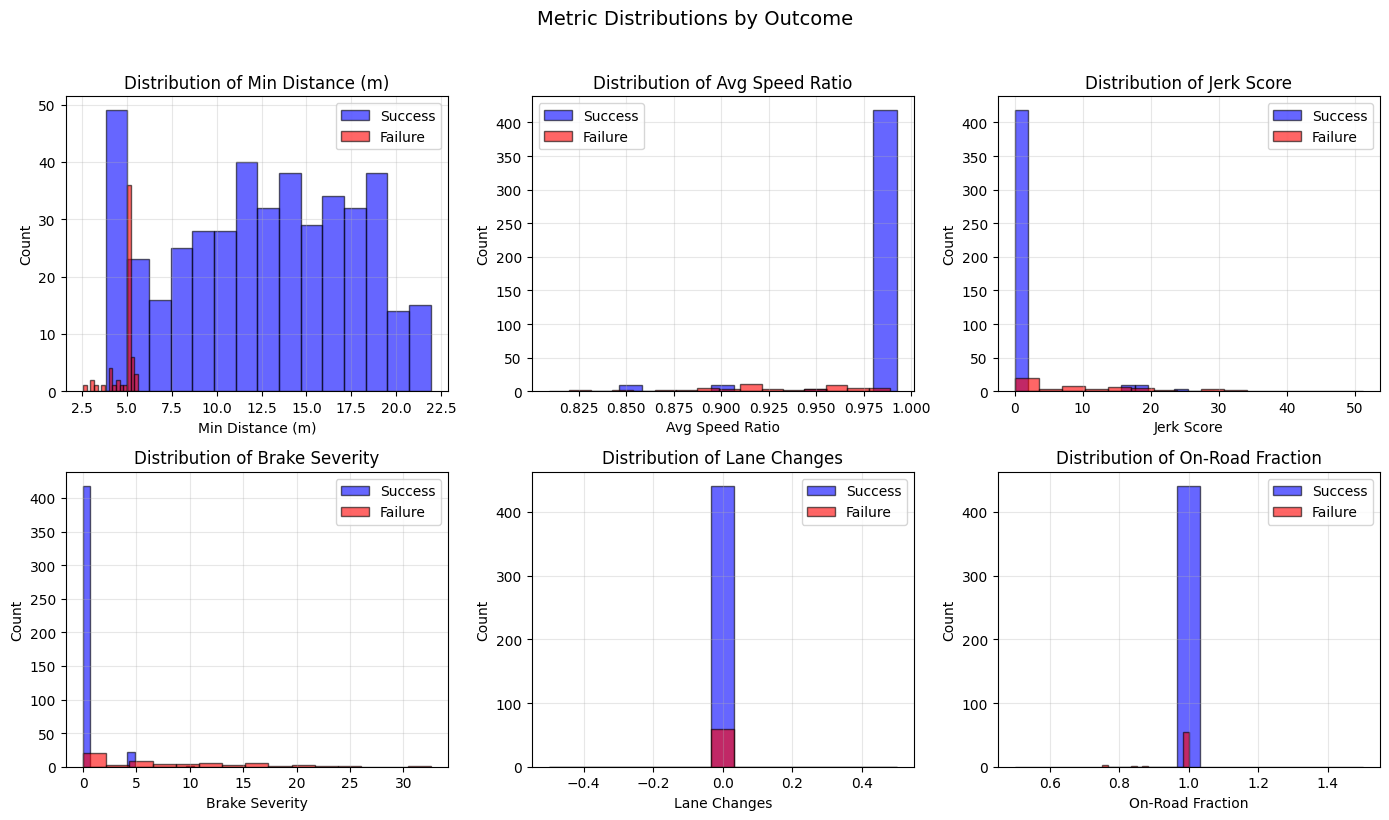


Summary: 59/500 failures (11.8%)
Log prob range: [-946.9, -282.2]


In [8]:
import matplotlib.pyplot as plt

# Extract data from logs
log_probs = [r["nominal_log_prob"] for r in logs]
failures = [r["is_failure"] for r in logs]

# Separate by outcome
success_logs = [r for r in logs if not r["is_failure"]]
failure_logs = [r for r in logs if r["is_failure"]]

# --- Plot 1: Log Probability vs Each Metric ---
metric_names = ["min_distance", "avg_speed_ratio", "jerk_score", "brake_severity", "lane_changes", "on_road_frac"]
metric_labels = ["Min Distance (m)", "Avg Speed Ratio", "Jerk Score", "Brake Severity", "Lane Changes", "On-Road Fraction"]

fig1, axes1 = plt.subplots(2, 3, figsize=(14, 8))
axes1 = axes1.flatten()

for idx, (metric, label) in enumerate(zip(metric_names, metric_labels)):
    ax = axes1[idx]
    
    # Get metric values and log probs for each outcome
    success_vals = [r["metrics"][metric] for r in success_logs]
    success_lps = [r["log_prob"] for r in success_logs]
    failure_vals = [r["metrics"][metric] for r in failure_logs]
    failure_lps = [r["nominal_log_prob"] for r in failure_logs]
    
    # Scatter plot: metric value vs log probability
    if success_vals:
        ax.scatter(success_vals, success_lps, alpha=0.6, label="Success", color="blue", edgecolor="black", s=30)
    if failure_vals:
        ax.scatter(failure_vals, failure_lps, alpha=0.6, label="Failure", color="red", edgecolor="black", s=30)
    
    ax.set_xlabel(label)
    ax.set_ylabel("Log Probability")
    ax.set_title(f"Log Prob vs {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Log Probability vs Robustness Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 2: Metric Distributions ---
fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
axes2 = axes2.flatten()

for idx, (metric, label) in enumerate(zip(metric_names, metric_labels)):
    ax = axes2[idx]
    
    success_vals = [r["metrics"][metric] for r in success_logs]
    failure_vals = [r["metrics"][metric] for r in failure_logs]
    
    if success_vals:
        ax.hist(success_vals, bins=15, alpha=0.6, label="Success", color="blue", edgecolor="black")
    if failure_vals:
        ax.hist(failure_vals, bins=15, alpha=0.6, label="Failure", color="red", edgecolor="black")
    
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Metric Distributions by Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
n_failures = len(failure_logs)
print(f"\nSummary: {n_failures}/{len(logs)} failures ({100*n_failures/len(logs):.1f}%)")
print(f"Log prob range: [{min(log_probs):.1f}, {max(log_probs):.1f}]")

## Fuzzing for Critical Failures

Use `ScenarioFuzzer` to find scenario parameters that minimize robustness while keeping scenarios plausible.

In [7]:
fuzzer = ScenarioFuzzer(env, model, robustness_weights=robustness_weights)

In [14]:
# Update fuzzer config for optimization
fuzzer.config = FuzzerConfig(
    n_samples=5, #3,           # rollouts per evaluation
    log_prob_weight=0.001,  # penalty for implausible scenarios
    verbose=True,
)

# Show parameter bounds
print("Parameter bounds:")
for name, (lo, hi), val in zip(PARAM_NAMES, fuzzer.config.bounds, fuzzer.config.initial_guess):
    print(f"  {name}: [{lo}, {hi}], initial={val}")

Parameter bounds:
  entering_vehicle_mu: [0, 150], initial=5.0
  other_vehicle_speed: [10, 25], initial=16.0
  ctrl_noise_p: [0.0, 0.5], initial=0.0
  initial_speed_mu: [0.0, 16.0], initial=8.0
  politeness_alpha: [0.1, 10.0], initial=1.0
  politeness_beta: [0.1, 10.0], initial=1.0
  pos_x_sigma: [0.001, 0.1], initial=0.005
  pos_y_sigma: [0.001, 0.1], initial=0.005
  vel_x_sigma: [0.001, 0.1], initial=0.005
  vel_y_sigma: [0.001, 0.1], initial=0.005


In [15]:
# Run optimization (WARNING: this can take a while)
# Uncomment to run
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

result = fuzzer.optimize(method="L-BFGS-B", maxiter=50)
print(f"\nOptimization finished: {result.message}")
print(f"Critical failure parameters:")
for name, val in fuzzer.get_params_dict(result.x).items():
    print(f"  {name}: {val:.4f}")
print(f"\nBest result: {fuzzer.best_result}")

[1] Rob: 0.8068 | LogProb: -623.38 | Obj: 1.4301
[2] Rob: 0.5105 | LogProb: -536.67 | Obj: 1.0472
[3] Rob: 0.6608 | LogProb: -608.68 | Obj: 1.2695
[4] Rob: 0.5277 | LogProb: -491.15 | Obj: 1.0188
[5] Rob: 0.8274 | LogProb: -640.72 | Obj: 1.4681
[6] Rob: 0.8244 | LogProb: -700.28 | Obj: 1.5246
[7] Rob: 0.8223 | LogProb: -540.33 | Obj: 1.3626
[8] Rob: 0.8285 | LogProb: -621.75 | Obj: 1.4503
[9] Rob: 0.6675 | LogProb: -622.97 | Obj: 1.2905
[10] Rob: 0.6793 | LogProb: -569.63 | Obj: 1.2489
[11] Rob: 0.6749 | LogProb: -573.04 | Obj: 1.2479
[12] Rob: 0.4125 | LogProb: -880.84 | Obj: 1.2934
[13] Rob: 0.5092 | LogProb: -865.83 | Obj: 1.3750
[14] Rob: 0.3380 | LogProb: -783.12 | Obj: 1.1211
[15] Rob: 0.4164 | LogProb: -896.26 | Obj: 1.3126
[16] Rob: 0.3274 | LogProb: -787.55 | Obj: 1.1150
[17] Rob: 0.3443 | LogProb: -886.26 | Obj: 1.2306
[18] Rob: 0.3371 | LogProb: -1005.13 | Obj: 1.3423
[19] Rob: 0.4442 | LogProb: -940.87 | Obj: 1.3850
[20] Rob: 0.5197 | LogProb: -858.53 | Obj: 1.3782
[21] Rob

In [16]:
fuzzer.best_result

{'eval': 27,
 'params': array([4.95776270e+01, 1.87668872e+01, 1.53715955e-01, 5.54054473e+00,
        7.23311281e-01, 3.76688719e+00, 3.77027236e-03, 3.42060315e-02,
        3.42060315e-02, 3.42060315e-02]),
 'robustness': np.float64(0.14393705207791135),
 'nominal_log_prob': np.float64(-474.61235961914065),
 'objective': np.float64(0.618549411697052)}

In [ ]:
env.close()

## Bayesian Failure Probability Estimation

Estimate p_fail with full uncertainty quantification using the Beta posterior.
Bayesian estimation is appropriate here because the ~33% failure rate means direct
sampling is already statistically efficient — importance sampling methods are designed
for rare events (pfail << 5%) and would add complexity without variance reduction benefit.

Failure Probability Estimation (59 failures in 500 rollouts)
  MLE (point estimate):    0.1180
  Bayesian posterior mean: 0.1195  ± 0.0145 (std)
  95% credible interval:   [0.0926, 0.1493]
  95% one-sided bound:     p_fail < 0.1441 with 95% confidence
  P(p_fail < 0.4):          1.0000


/Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/Users/dkoffical/envs/myenv312/lib/python3.12/site-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/Users/dk

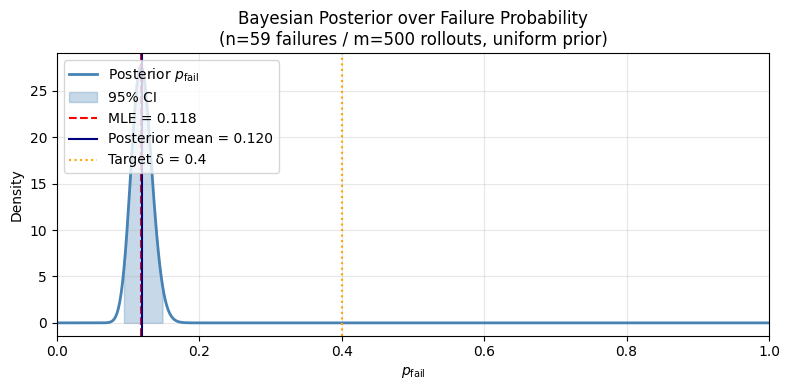

In [10]:
from src.failure_probability import estimate_failure_probability, print_failure_probability_report
import numpy as np
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt

# Estimate failure probability from the collected rollout logs
# Uniform prior Beta(1, 1) — no prior bias toward safe or unsafe
TARGET_DELTA = 0.4  # safety threshold: we want p_fail < this

result = estimate_failure_probability(logs, prior_alpha=1.0, prior_beta=1.0, target_delta=TARGET_DELTA)
print_failure_probability_report(result, target_delta=TARGET_DELTA)

# --- Plot posterior distribution over p_fail ---
fig, ax = plt.subplots(figsize=(8, 4))

p_vals = np.linspace(0, 1, 500)
posterior = beta_dist(result["posterior_alpha"], result["posterior_beta"])
ax.plot(p_vals, posterior.pdf(p_vals), color="steelblue", linewidth=2, label="Posterior $p_{\\mathrm{fail}}$")

# Shade 95% credible interval
ci_mask = (p_vals >= result["ci_95_low"]) & (p_vals <= result["ci_95_high"])
ax.fill_between(p_vals[ci_mask], posterior.pdf(p_vals[ci_mask]), alpha=0.3, color="steelblue", label="95% CI")

# Mark point estimates
ax.axvline(result["mle"], color="red", linestyle="--", linewidth=1.5, label=f"MLE = {result['mle']:.3f}")
ax.axvline(result["posterior_mean"], color="navy", linestyle="-", linewidth=1.5, label=f"Posterior mean = {result['posterior_mean']:.3f}")
ax.axvline(TARGET_DELTA, color="orange", linestyle=":", linewidth=1.5, label=f"Target δ = {TARGET_DELTA}")

ax.set_xlabel("$p_{\\mathrm{fail}}$")
ax.set_ylabel("Density")
ax.set_title(f"Bayesian Posterior over Failure Probability\n"
             f"(n={result['n_failures']} failures / m={result['n_rollouts']} rollouts, "
             f"uniform prior)")
ax.legend(loc="upper left")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()